# SPOmiAlign Demo: Image to Image Section Alignment

This notebook follows a fixed workflow:
1. Input unaligned slices (paired images)
2. Imaging (generation of spatial structural images, SSI)
3. Sections matching and warpping
4. Reassignment
5. Output aligned slices


## 1. Input unaligned slices (paired images)

In [1]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial import cKDTree

%matplotlib inline

NOTEBOOK_DIR = Path().resolve()
DEMO_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = DEMO_DIR.parent
sys.path.append(str(PROJECT_ROOT / "SPOmiAlign"))
sys.path.append(str(PROJECT_ROOT / "new" / "Code"))

from align_h5ad_to_h5ad_square import (
    build_render_meta,
    render_h5ad,
    render_transformed_source_in_target_render_space,
    resolve_coordinate_config,
)
from reassignment_direction import (
    build_reassigned_h5ad_from_mapping,
    cmap_blue,
    cmap_orange,
    get_spatial_from_adata,
    mean_internal_nn_distance,
    plot_h5ad_umi_squares,
)
from roma import align_and_process_images


def _first_existing_path(candidates):
    for candidate in candidates:
        if candidate is None:
            continue
        candidate = Path(candidate).expanduser()
        if candidate.exists():
            return candidate
    return None


def _read_image(path):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f"Failed to read image: {path}")
    return image


def _show_bgr(ax, image_path, title):
    image = _read_image(image_path)
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")


def _fit_to_reference_canvas(reference_img, moving_img):
    ref_h, ref_w = reference_img.shape[:2]
    mov_h, mov_w = moving_img.shape[:2]
    canvas = np.full((ref_h, ref_w, 3), 255, dtype=np.uint8)
    canvas[: min(ref_h, mov_h), : min(ref_w, mov_w)] = moving_img[: min(ref_h, mov_h), : min(ref_w, mov_w)]
    return canvas


def _make_overlay(reference_path, moving_path, out_path, alpha_reference=0.55, alpha_moving=0.45):
    reference_img = _read_image(reference_path)
    moving_img = _read_image(moving_path)
    moving_canvas = _fit_to_reference_canvas(reference_img, moving_img)
    overlay = cv2.addWeighted(reference_img, alpha_reference, moving_canvas, alpha_moving, 0)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path), overlay)
    return out_path


def _prepare_directional_inputs(st_h5ad_path, sm_h5ad_path, aligned_sm_h5ad_path, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    st_adata = sc.read_h5ad(str(st_h5ad_path))
    st_adata.obsm["spatial_raw"] = np.asarray(st_adata.obsm["spatial"]).copy()
    st_with_keys_path = out_dir / "st_with_reference_keys.h5ad"
    st_adata.write_h5ad(str(st_with_keys_path), compression="gzip")

    sm_raw_adata = sc.read_h5ad(str(sm_h5ad_path))
    sm_aligned_adata = sc.read_h5ad(str(aligned_sm_h5ad_path))
    raw_xy = np.asarray(sm_raw_adata.obsm["spatial"]).copy()
    aligned_xy = np.asarray(sm_aligned_adata.obsm["spatial"]).copy()
    if raw_xy.shape[0] != aligned_xy.shape[0]:
        raise ValueError("The original SM and aligned SM H5AD files do not have the same number of spots.")
    sm_aligned_adata.obsm["spatial_raw"] = raw_xy
    sm_aligned_adata.obsm["spatial_spomialign"] = aligned_xy.copy()
    sm_aligned_adata.obsm["spatial"] = aligned_xy.copy()
    sm_with_keys_path = out_dir / "sm_with_spomialign.h5ad"
    sm_aligned_adata.write_h5ad(str(sm_with_keys_path), compression="gzip")
    return st_with_keys_path, sm_with_keys_path


def _run_directional_reassignment_fixed_roles(s1_h5ad, s2_h5ad, direction, out_dir, plot_dir, s1_spatial_key, s2_spatial_key):
    out_dir.mkdir(parents=True, exist_ok=True)
    plot_dir.mkdir(parents=True, exist_ok=True)
    adata_s1 = sc.read_h5ad(str(s1_h5ad))
    adata_s2 = sc.read_h5ad(str(s2_h5ad))
    high_xy = get_spatial_from_adata(adata_s1, s1_spatial_key)
    low_xy = get_spatial_from_adata(adata_s2, s2_spatial_key)

    def _clean_xy(xy):
        mask = np.isfinite(xy).all(axis=1)
        return xy[mask, :], mask

    high_xy_clean, high_mask = _clean_xy(high_xy)
    low_xy_clean, low_mask = _clean_xy(low_xy)
    mean_high, _ = mean_internal_nn_distance(high_xy_clean)
    mean_low, nn_low = mean_internal_nn_distance(low_xy_clean)
    d_ref_max = float(np.max(nn_low)) if nn_low.size > 0 else 0.0
    print(f"Using fixed roles for {direction}:")
    print("  S1 / aligned SM = high resolution")
    print("  S2 / reference ST = low resolution")
    print(f"  S1 mean NN distance: {mean_high:.4f}")
    print(f"  S2 mean NN distance: {mean_low:.4f}")
    high_indices_all = np.where(high_mask)[0]
    low_indices_all = np.where(low_mask)[0]
    tree_low = cKDTree(low_xy_clean)
    dist, idx = tree_low.query(high_xy_clean, k=1)
    valid = dist <= 2.0 * d_ref_max if d_ref_max > 0 else np.ones_like(dist, dtype=bool)
    high_idx_clean = high_indices_all[valid]
    low_idx_clean = low_indices_all[idx[valid]]
    dist_f = dist[valid]
    if direction == "high_to_low":
        mapping = pd.DataFrame({"source_index": high_idx_clean, "target_index": low_idx_clean, "source_x": high_xy_clean[valid][:, 0], "source_y": high_xy_clean[valid][:, 1], "target_x": low_xy_clean[idx[valid]][:, 0], "target_y": low_xy_clean[idx[valid]][:, 1], "distance": dist_f})
        out_h5ad = out_dir / "reassigned_high_to_low_on_st.h5ad"
        reassigned_cmap = cmap_orange
    else:
        mapping = pd.DataFrame({"source_index": low_idx_clean, "target_index": high_idx_clean, "source_x": low_xy_clean[idx[valid]][:, 0], "source_y": low_xy_clean[idx[valid]][:, 1], "target_x": high_xy_clean[valid][:, 0], "target_y": high_xy_clean[valid][:, 1], "distance": dist_f})
        out_h5ad = out_dir / "reassigned_low_to_high_on_sm.h5ad"
        reassigned_cmap = cmap_blue
    meta = {"low_res_name": "S2", "high_res_name": "S1", "d_ref_max": d_ref_max, "reassignment_direction": direction, "s1_spatial_key": s1_spatial_key, "s2_spatial_key": s2_spatial_key}
    map_csv = out_dir / f"{direction}_mapping.csv"
    mapping.to_csv(map_csv, index=False)
    plot_h5ad_umi_squares(adata_s1, out_png=str(plot_dir / "S1_umi.png"), title=f"S1 UMI ({s1_spatial_key})", spatial_key=s1_spatial_key, cmap=cmap_orange)
    plot_h5ad_umi_squares(adata_s2, out_png=str(plot_dir / "S2_umi.png"), title=f"S2 UMI ({s2_spatial_key})", spatial_key=s2_spatial_key, cmap=cmap_blue)
    adata_new = build_reassigned_h5ad_from_mapping(mapping=mapping, meta=meta, adata_s1=adata_s1, adata_s2=adata_s2, out_h5ad=str(out_h5ad), scale_by_mapping_factor=True, reserved_col=None)
    plot_h5ad_umi_squares(adata_new, out_png=str(plot_dir / f"reassigned_{direction}_umi.png"), title=f"Reassigned ({direction}) UMI", spatial_key="spatial", cmap=reassigned_cmap)
    return out_h5ad, map_csv, meta


def _label_for_dataset(dataset_name):
    if dataset_name == "S1":
        return "S1: aligned SM"
    if dataset_name == "S2":
        return "S2: reference ST"
    return dataset_name


env_data_dir = os.environ.get("SPOMIALIGN_R114_DIR")
data_candidates = []
if env_data_dir:
    data_candidates.append(Path(env_data_dir))
data_candidates.extend([Path("/storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_h5ad/R114"), PROJECT_ROOT / "new" / "Data" / "standardized_data" / "R114"])
DATA_DIR = _first_existing_path(data_candidates)
if DATA_DIR is None:
    raise FileNotFoundError("R114 data directory not found.")
SAVE_ROOT = Path(os.environ.get("SPOMIALIGN_DEMO_SAVE_DIR", DEMO_DIR / "output")).expanduser()
SAVE_PATH = SAVE_ROOT / "h5ad_2_h5ad" / "R114"
SAVE_PATH.mkdir(parents=True, exist_ok=True)
h5ad_img1_path = DATA_DIR / "st.h5ad"
h5ad_img2_path = DATA_DIR / "sm.h5ad"
TARGET_ROTATE = 0.0
SOURCE_ROTATE = -90.0
DISPLAY_LONG_SIDE = 2200
PADDING = 0
METHOD = "affine+bspline"
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {SAVE_PATH}")
print(f"Target ST: {h5ad_img1_path}")
print(f"Source SM: {h5ad_img2_path}")


Data directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_h5ad/R114
Output directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114
Target ST: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_h5ad/R114/st.h5ad
Source SM: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_h5ad/R114/sm.h5ad


## 2. Imaging (generation of spatial structural images, SSI)

[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114/rendering/st_render.png (2159x2200, background=white, shape=square, points=2201)
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114/rendering/sm_render.png (1784x2200, background=white, shape=square, points=9522)


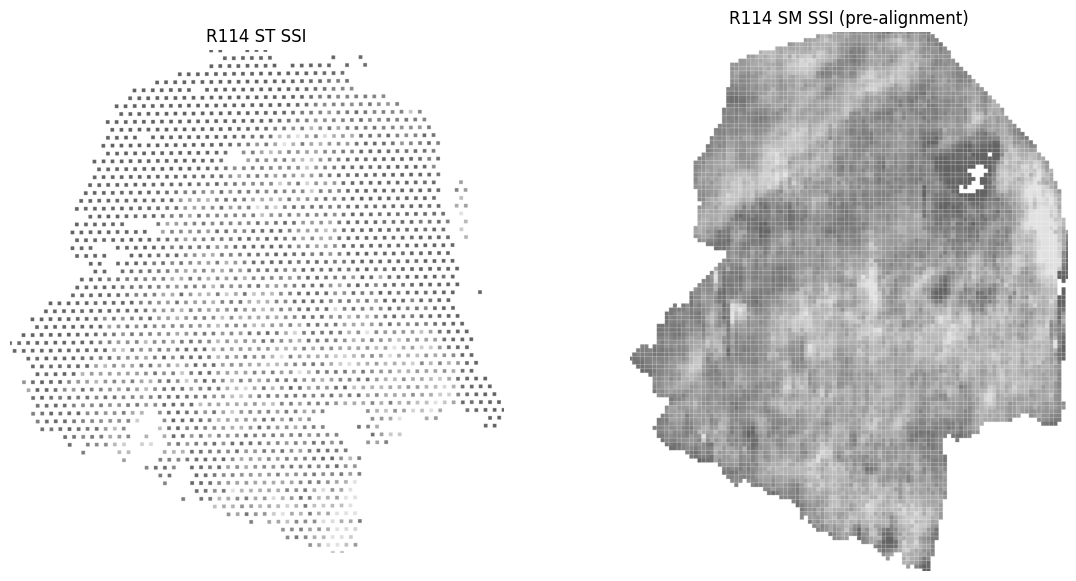

In [2]:
%matplotlib inline
render_dir = SAVE_PATH / "rendering"
render_dir.mkdir(parents=True, exist_ok=True)
target_coord_config = resolve_coordinate_config(h5ad_path=h5ad_img1_path, label="target/ST", spatial_key="spatial", x_obs_col=None, y_obs_col=None)
source_coord_config = resolve_coordinate_config(h5ad_path=h5ad_img2_path, label="source/SM", spatial_key="spatial", x_obs_col=None, y_obs_col=None)
target_render_meta = build_render_meta(input_h5ad=h5ad_img1_path, coord_config=target_coord_config, rotate=TARGET_ROTATE, scale=1.0, flip_horizontal=False, display_long_side=DISPLAY_LONG_SIDE, padding=PADDING)
source_render_meta = build_render_meta(input_h5ad=h5ad_img2_path, coord_config=source_coord_config, rotate=SOURCE_ROTATE, scale=1.0, flip_horizontal=False, display_long_side=DISPLAY_LONG_SIDE, padding=PADDING)
target_render_style = {"render_mode": "scatter", "background": "white", "display_long_side": DISPLAY_LONG_SIDE, "padding": PADDING, "point_shape": "square", "point_radius": 5, "intensity_mode": "X_sum", "intensity_obs_col": None, "intensity_log_transform": False, "threshold_percentile": None, "enhance": False, "marker_alpha": 0.95, "gray_min": 0.35, "gray_max": 0.88}
source_render_style = {"render_mode": "scatter", "background": "white", "display_long_side": DISPLAY_LONG_SIDE, "padding": PADDING, "point_shape": "square", "point_radius": 5, "intensity_mode": "X_sum", "intensity_obs_col": None, "intensity_log_transform": False, "threshold_percentile": None, "enhance": False, "marker_alpha": 0.95, "gray_min": 0.35, "gray_max": 0.88}
Gen_img1_path = render_dir / "st_render.png"
Gen_img2_path = render_dir / "sm_render.png"
render_h5ad(input_h5ad=h5ad_img1_path, output_png=Gen_img1_path, coord_config=target_coord_config, render_meta=target_render_meta, render_style=target_render_style)
render_h5ad(input_h5ad=h5ad_img2_path, output_png=Gen_img2_path, coord_config=source_coord_config, render_meta=source_render_meta, render_style=source_render_style)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
_show_bgr(axes[0], Gen_img1_path, "R114 ST SSI")
_show_bgr(axes[1], Gen_img2_path, "R114 SM SSI (pre-alignment)")
plt.show()


## 3. Sections matching and warpping

Using device: cuda:0


2026-04-13 00:28:19.813 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 1152)


Running RoMa matching...
Estimating affine+bspline transform...
Warping images...
Padding fill color: (255, 255, 255)
Processing H5AD coordinates...
[OK] Step 00 source coordinates mapped to render space: 9522/9522 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114/alignment/debug_step_00_source_in_render_space.png
📝 Columns not found or not specified. Updating adata.obsm['spatial']
[OK] Step 02 after resize to registration grid (source resized canvas): 9520/9522 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114/alignment/debug_step_02_after_resize_to_registration.png
📝 Columns not found or not specified. Updating adata.obsm['spatial']
[OK] Step 03 after registration transform (target resized canvas): 9522/9522 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114/alignment/debug_step_03_after_registration_transform.png
[OK] Step 04 a

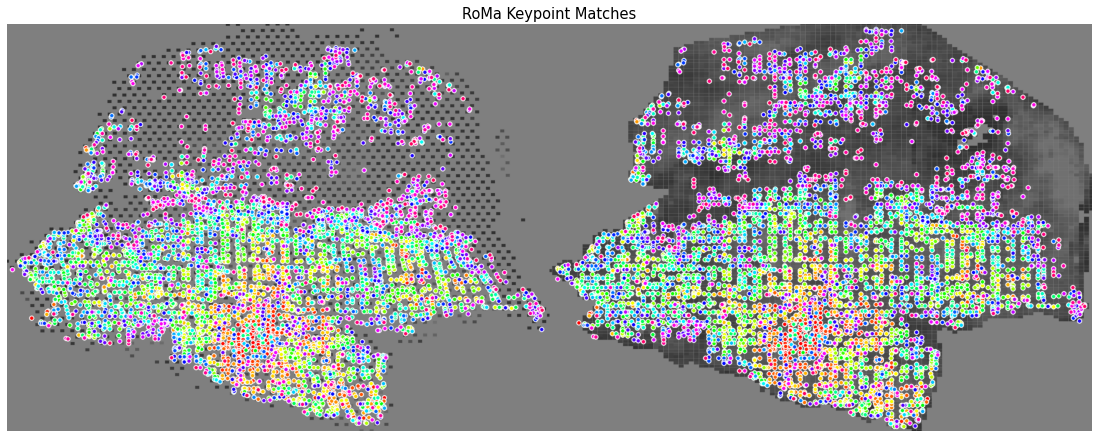

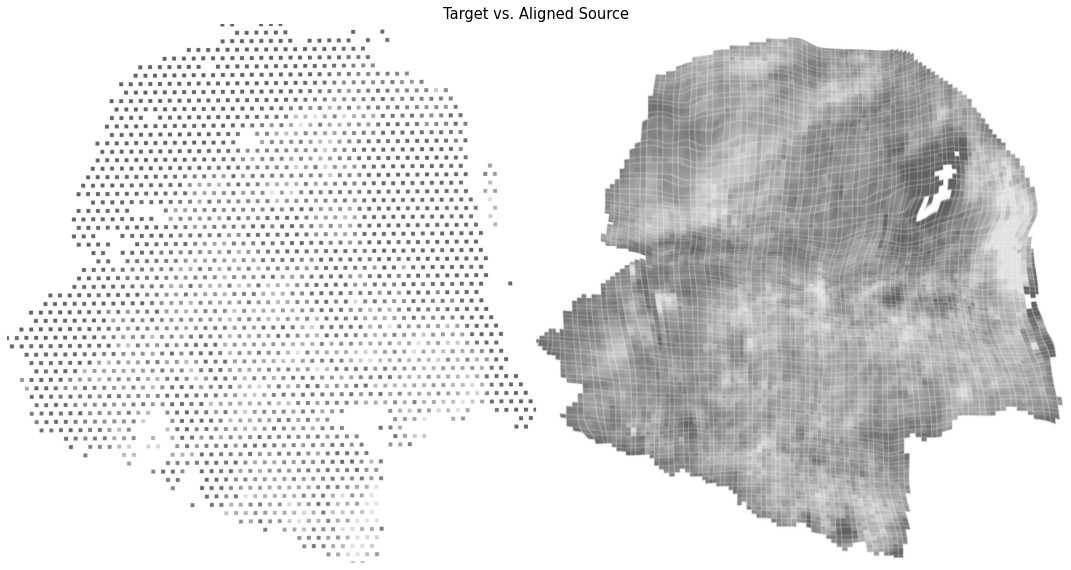

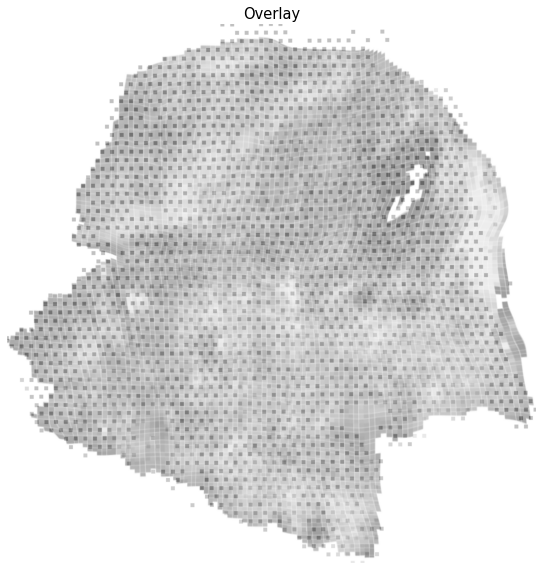

Alignment runtime: 6.1952 seconds
Done. Results saved to /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114/alignment
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114/alignment/transformed_sm_in_st_frame.png (2159x2200, background=white, shape=square, points=9522)


PosixPath('/storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114/alignment/overlay_after_alignment.png')

In [3]:
alignment_dir = SAVE_PATH / "alignment"
alignment_dir.mkdir(parents=True, exist_ok=True)
before_overlay_path = alignment_dir / "overlay_before_alignment.png"
_make_overlay(Gen_img1_path, Gen_img2_path, before_overlay_path)
align_and_process_images(img1_path=str(Gen_img1_path), img2_path=str(Gen_img2_path), h5ad_path=str(h5ad_img2_path), method=METHOD, output_dir=str(alignment_dir), spatial_key=str(source_coord_config["spatial_key"] or "spatial"), x_obs_col=source_coord_config["x_obs_col"], y_obs_col=source_coord_config["y_obs_col"], rotate=0.0, scale=1.0, origin=np.asarray(source_render_meta["rotation_origin"], dtype=np.float64), auto_upscale_reference=False, source_render_meta=source_render_meta, target_render_meta=target_render_meta)
transformed_h5ad_path = alignment_dir / "transformed.h5ad"
transformed_source_png = alignment_dir / "transformed_sm_in_st_frame.png"
render_transformed_source_in_target_render_space(transformed_h5ad=transformed_h5ad_path, transformed_coord_config=source_coord_config, output_png=transformed_source_png, target_render_meta=target_render_meta, source_render_style=source_render_style)
after_overlay_path = alignment_dir / "overlay_after_alignment.png"
_make_overlay(Gen_img1_path, transformed_source_png, after_overlay_path)


## 4. Reassignment

The reassignment step below does not auto-infer high/low resolution. It always uses:
- `S1 / aligned SM` as high resolution
- `S2 / reference ST` as low resolution

In [4]:
directional_input_dir = SAVE_PATH / "directional_inputs"
st_with_keys_path, sm_with_keys_path = _prepare_directional_inputs(st_h5ad_path=h5ad_img1_path, sm_h5ad_path=h5ad_img2_path, aligned_sm_h5ad_path=transformed_h5ad_path, out_dir=directional_input_dir)
high_to_low_dir = SAVE_PATH / "high_to_low"
high_to_low_plot_dir = high_to_low_dir / "plots"
high_to_low_out_h5ad, high_to_low_map_csv, high_to_low_meta = _run_directional_reassignment_fixed_roles(s1_h5ad=sm_with_keys_path, s2_h5ad=st_with_keys_path, direction="high_to_low", out_dir=high_to_low_dir, plot_dir=high_to_low_plot_dir, s1_spatial_key="spatial_spomialign", s2_spatial_key="spatial_raw")
low_to_high_dir = SAVE_PATH / "low_to_high"
low_to_high_plot_dir = low_to_high_dir / "plots"
low_to_high_out_h5ad, low_to_high_map_csv, low_to_high_meta = _run_directional_reassignment_fixed_roles(s1_h5ad=sm_with_keys_path, s2_h5ad=st_with_keys_path, direction="low_to_high", out_dir=low_to_high_dir, plot_dir=low_to_high_plot_dir, s1_spatial_key="spatial_spomialign", s2_spatial_key="spatial_raw")


Using fixed roles for high_to_low:
  S1 / aligned SM = high resolution
  S2 / reference ST = low resolution
  S1 mean NN distance: 142.0473
  S2 mean NN distance: 366.3777

===== S1 UMI (spatial_spomialign) =====
value source: X.sum(axis=1)
n spots: 9522
x range: 3965.129 ~ 23675.020
y range: 4859.353 ~ 24484.260
value range: 515304.812 ~ 4592099.500
value q1/q50/q99: 818407.541, 2059662.688, 3480026.267
自动估计 spot_size = 6.83
✅ UMI 可视化已保存：/storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114/high_to_low/plots/S1_umi.png

===== S2 UMI (spatial_raw) =====
value source: obs['total_counts']
n spots: 2201
x range: 3881.000 ~ 23850.000
y range: 4337.000 ~ 24694.000
value range: 209.000 ~ 35930.000
value q1/q50/q99: 274.000, 5697.000, 28591.000
自动估计 spot_size = 83.06
✅ UMI 可视化已保存：/storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/R114/high_to_low/plots/S2_umi.png

开始构建 high_to_low 的新 h5ad ...
写出前 X 类型: <class 'scipy.sparse._csr.csr_matrix'>
✅ 新 

## 5. Output aligned slices

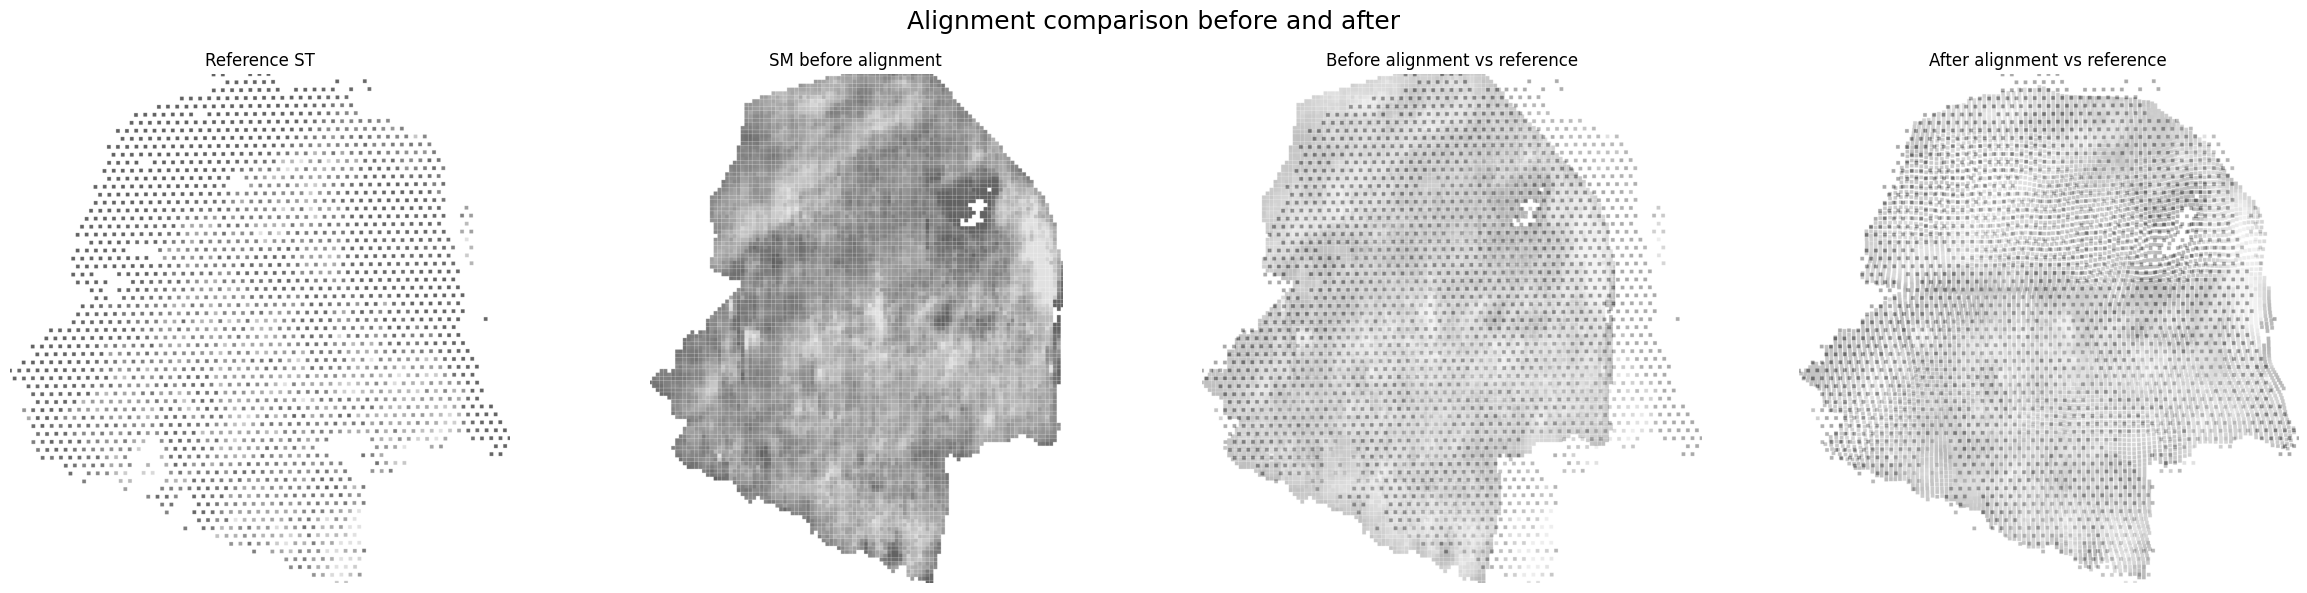

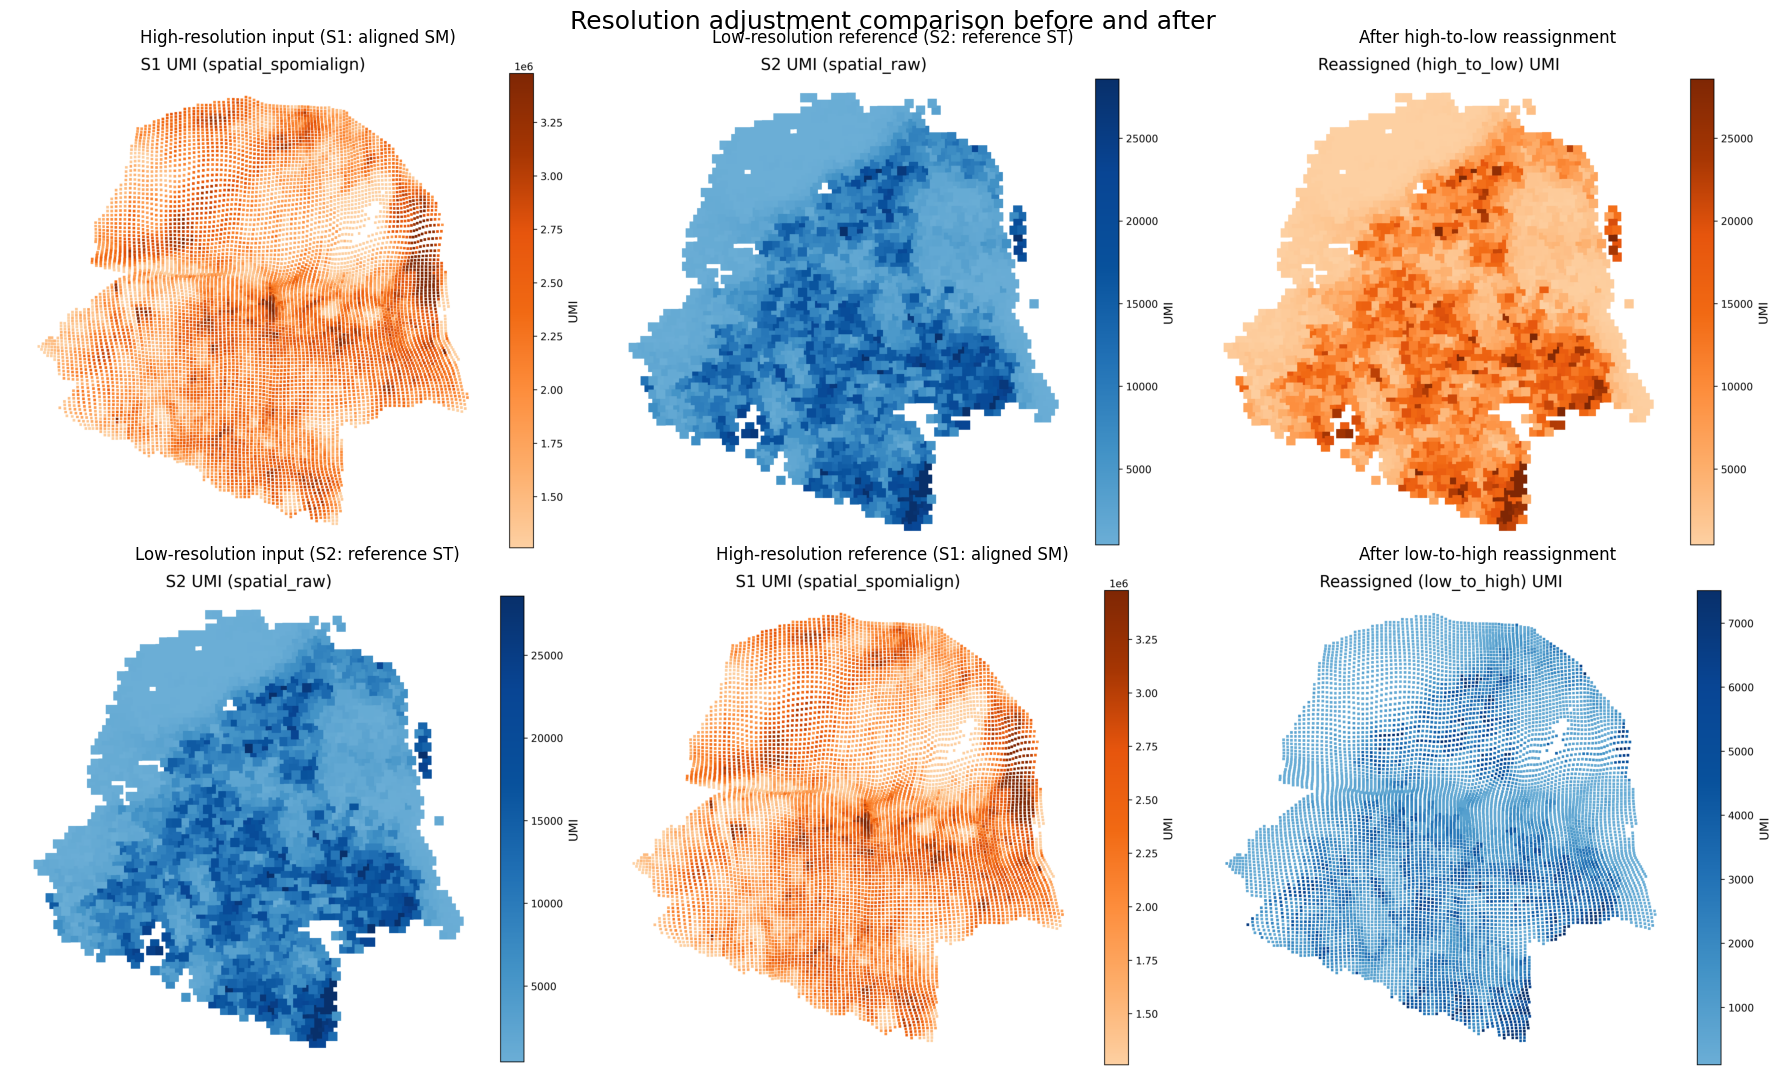

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
_show_bgr(axes[0], Gen_img1_path, "Reference ST")
_show_bgr(axes[1], Gen_img2_path, "SM before alignment")
_show_bgr(axes[2], before_overlay_path, "Before alignment vs reference")
_show_bgr(axes[3], after_overlay_path, "After alignment vs reference")
fig.suptitle("Alignment comparison before and after", fontsize=18)
plt.tight_layout()
plt.show()
high_low_low_name = high_to_low_meta["low_res_name"]
high_low_high_name = high_to_low_meta["high_res_name"]
low_high_low_name = low_to_high_meta["low_res_name"]
low_high_high_name = low_to_high_meta["high_res_name"]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
_show_bgr(axes[0, 0], high_to_low_plot_dir / f"{high_low_high_name}_umi.png", f"High-resolution input ({_label_for_dataset(high_low_high_name)})")
_show_bgr(axes[0, 1], high_to_low_plot_dir / f"{high_low_low_name}_umi.png", f"Low-resolution reference ({_label_for_dataset(high_low_low_name)})")
_show_bgr(axes[0, 2], high_to_low_plot_dir / "reassigned_high_to_low_umi.png", "After high-to-low reassignment")
_show_bgr(axes[1, 0], low_to_high_plot_dir / f"{low_high_low_name}_umi.png", f"Low-resolution input ({_label_for_dataset(low_high_low_name)})")
_show_bgr(axes[1, 1], low_to_high_plot_dir / f"{low_high_high_name}_umi.png", f"High-resolution reference ({_label_for_dataset(low_high_high_name)})")
_show_bgr(axes[1, 2], low_to_high_plot_dir / "reassigned_low_to_high_umi.png", "After low-to-high reassignment")
fig.suptitle("Resolution adjustment comparison before and after", fontsize=18)
plt.tight_layout()
plt.show()
